# Substrates
  
### Benchmark substrate potentials: different wells and symmetries
  
  The cluster moves on a rigid substrate potential.
  It is defined either as a lattice of repeated potential wells
  or as a superposition of plane waves (which can also represent a quasicrystal).
  
  For the plane-wave (sinusoidal) substrate, the number of waves and their
  relative phases control the symmetry; the amplitude is set by $\epsilon$.
  
  For lattice-based substrates, the repeated unit (the "well") can be any
  smooth function — in practice it should vanish at the cell boundary to
  avoid discontinuities.

In [1]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt

from flake.substrate import (calc_matrices_bvect,
                              particle_en_gaussian,
                              particle_en_sin,
                              particle_en_tanh,
                              gaussian, get_ks,
                              substrate_from_params)
from flake.plot import (get_brillouin_zone_2d, plot_BZ2d,
                        plot_UC, plot_lattice_vectors)

### Lattice substrate
  
  A lattice substrate is defined by two primitive vectors, just like a cluster.
  `calc_matrices_bvect` returns both the direct-space matrix $\mathbf{u}$
  (columns are $\mathbf{b}_1$, $\mathbf{b}_2$) and its inverse $\mathbf{u}^{-1}$
  (used for fractional coordinates).
  
#### Substrate symmetry

In [2]:
# Substrate primitive vectors.
# Uncomment the geometry you want; only one should be active at a time.
# If sin potential, you should match the lattice with the wave vector

# Triangular lattice, spacing R=1
R = 1.0
b1 = np.array([R, 0.])
b2 = np.array([-R/2., R*sqrt(3.)/2.])
u, u_inv = calc_matrices_bvect(b1, b2)
sym = 'triangular'

# Square lattice, spacing R=1
# R = 1.0
# b1 = np.array([R, 0.])
# b2 = np.array([0., R])
# u, u_inv = calc_matrices_bvect(b1, b2)
# sym = 'square'

# Oblique example
# b1 = np.array([1., 0.])
# b2 = np.array([0., 2.])
# u, u_inv = calc_matrices_bvect(b1, b2)
# sym = 'oblique'

print('Lattice: %s, b1=%s, b2=%s' % (sym, b1, b2))

Lattice: triangular, b1=[1. 0.], b2=[-0.5        0.8660254]


#### Basis
  
  The Bravais lattice can be decorated with a multi-site basis.
  For most substrates a single site at the origin is sufficient.

In [3]:
# Substrate basis: list of (2,) positions within the unit cell.
basis = [np.array([0., 0.])]

# Decorated examples (uncomment to try):
# basis = [np.array([0., 0.]), np.array([0.5, sqrt(3)/6.])]  # honeycomb

#### Well shape
  
  This is the function repeated at each lattice site (`gaussian` / `tanh`),
  or the set of plane-wave vectors defining a sinusoidal landscape (`sin`).
  
  The sinusoidal substrate energy is:
  
  $$V(\mathbf{r}) = -\epsilon \, c_n \sum_{l=1}^{n} \cos(\mathbf{k}_l \cdot \mathbf{r})$$
  
  where the $n$ wave vectors $\mathbf{k}_l$ are generated by `get_ks`.
  The normalisation $c_n$ is chosen so that the global minimum is $-\epsilon$.
  
  > **Note:** `alpha_n` in `get_ks` is in **radians**.
  > For square symmetry use `alpha_n = np.pi/4`, not `45.`.


In [4]:
# Choose substrate type: 'gaussian', 'tanh', 'sin'
sub_type = 'sin'

if sub_type == 'gaussian':
    # Gaussian well: smooth, localized, vanishes at r=b.
    # Ref: Cao, Silva et al., Phys. Rev. X 12, 021059 (2022)
    epsilon, sigma, a, b = 1., 0.1, 0.2, 0.45
    en_inputs = [basis, a, b, sigma, epsilon, u, u_inv]
    en_func   = particle_en_gaussian
    title     = 'Gaussian well, %s lattice' % sym

elif sub_type == 'tanh':
    # Tanh well: flat bottom with steep walls, width controlled by ww.
    # Ref: Cao et al., Phys. Rev. E 103, 012606 (2021)
    epsilon, ww, a, b = 1., 0.25, 0.1, 0.45
    en_inputs = [basis, a, b, ww, epsilon, u, u_inv]
    en_func   = particle_en_tanh
    title     = 'Tanh well, %s lattice' % sym

elif sub_type == 'sin':
    # Plane-wave (sinusoidal) substrate: sum of n plane waves.
    # Ref: Vanossi, Manini, Tosatti, PNAS 109, 16429 (2012)
    # get_ks(R, n, c_n, alpha_n) generates the n wave vectors:
    #   R      -- lattice spacing (sets the length scale)
    #   n      -- number of waves (controls symmetry)
    #   c_n    -- normalisation constant so that E_min = -epsilon
    #   alpha_n -- global rotation of the wave-vector set [degrees]
    n, c_n, alpha_n = 3, 4./3., 0.       # triangular symmetry
    # n, c_n, alpha_n = 2, 1., 0.         # parallel lines (1D)
    # n, c_n, alpha_n = 4, sqrt(2), np.pi/4.   # square symmetry
    # n, c_n, alpha_n = 5, 2., 0.         # 5-fold quasicrystal
    epsilon = 1.
    ks      = get_ks(R, n, c_n, alpha_n)
    en_inputs = [basis, ks, epsilon]
    en_func   = particle_en_sin
    title     = 'Sinusoidal, n=%i-fold' % n

else:
    raise ValueError('Unknown sub_type: %r' % sub_type)

### Visualising the substrate
  
#### 2D energy and force maps
  
  We evaluate the substrate energy $E$, force $\mathbf{F} = -\nabla E$,
  and torque $\tau = -\partial E / \partial \theta$ on a 2D grid.
  The torque is computed with respect to the origin; for an extended layer
  it is not physically meaningful on its own, but it is useful for debugging.

In [5]:
side = 2.5
nx, ny = 200, 200
xx, yy = np.meshgrid(np.linspace(-side, side, nx),
                     np.linspace(-side, side, ny))
# Flatten to (N,2) -- substrate functions expect a list of positions.
p = np.stack([xx.ravel(), yy.ravel()], axis=1)

en, F, tau = en_func(p, np.array([0., 0.]), *en_inputs)

# 1D cross-section along x for profile plots.
x_line = np.linspace(0., side, 4*nx)
p_line = np.stack([x_line, np.zeros_like(x_line)], axis=1)
en_line, F_line, tau_line = en_func(p_line, np.array([0., 0.]), *en_inputs)

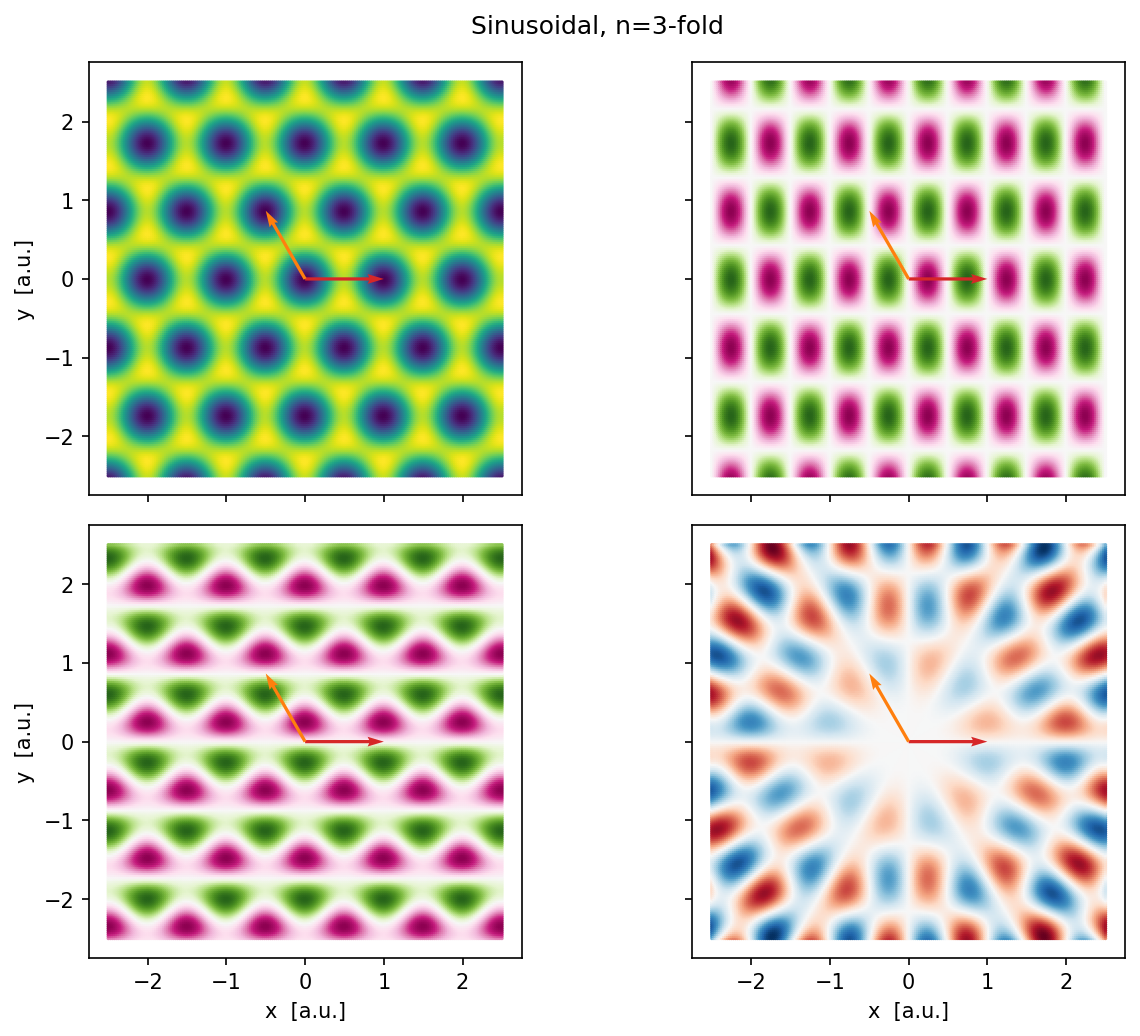

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), dpi=150,
                         sharex=True, sharey=True)
fig.suptitle(title)
(axE, axFx), (axFy, axTau) = axes

s0 = 0.5   # scatter marker size -- tiny to approximate a continuous map
S  = u_inv.T if sub_type != 'sin' else np.array([b1, b2])

for ax, vals, label, cmap in [
    (axE,   en,     r'$E$',    'viridis'),
    (axFx,  F[:,0], r'$F_x$',  'PiYG'),
    (axFy,  F[:,1], r'$F_y$',  'PiYG'),
    (axTau, tau,    r'$\tau$', 'RdBu'),
]:
    sc = ax.scatter(p[:,0], p[:,1], c=vals, s=s0, cmap=cmap, rasterized=True)
    #plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    plot_lattice_vectors(ax, S)
    if sub_type != 'sin':
        plot_BZ2d(ax, get_brillouin_zone_2d(S),
                  {'ls': '--', 'color': 'gray', 'lw': 0.8, 'fill': False})
    ax.set_aspect('equal')

axFy.set_xlabel('x  [a.u.]')
axTau.set_xlabel('x  [a.u.]')
axE.set_ylabel('y  [a.u.]')
axFy.set_ylabel('y  [a.u.]')
plt.tight_layout()
plt.show()

#### 1D cross-section along $x$
  
  The same quantities along the horizontal line $y = 0$.



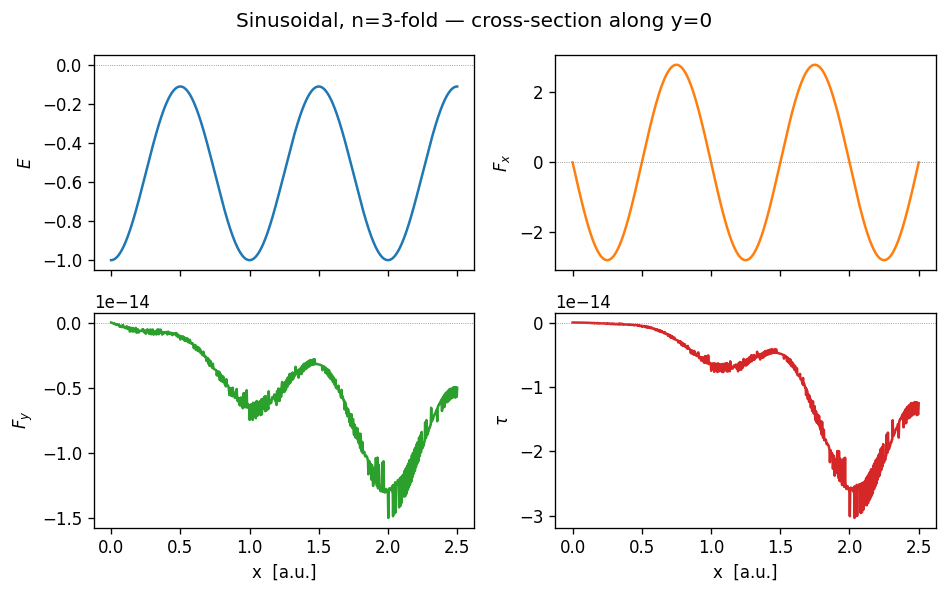

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), dpi=120, sharex=True)
fig.suptitle(title + ' — cross-section along y=0')
(axE, axFx), (axFy, axTau) = axes

axE.plot(x_line,   en_line,     color='tab:blue')
axFx.plot(x_line,  F_line[:,0], color='tab:orange')
axFy.plot(x_line,  F_line[:,1], color='tab:green')
axTau.plot(x_line, tau_line,    color='tab:red')

for ax, label in [(axE, r'$E$'), (axFx, r'$F_x$'),
                  (axFy, r'$F_y$'), (axTau, r'$\tau$')]:
    ax.set_ylabel(label)
    ax.axhline(0, color='gray', lw=0.5, ls=':')
axFy.set_xlabel('x  [a.u.]')
axTau.set_xlabel('x  [a.u.]')
plt.tight_layout()
plt.show()

### Substrate from parameter dictionary
  
  In practice, the substrate is loaded from a YAML file via `substrate_from_params`.
  It returns three objects:
  
  - `pen_func`: per-particle energy/force/torque (one value per site)
  - `en_func`: total energy/force/torque summed over the whole cluster
  - `en_inputs`: always an empty list — all parameters are captured in a closure
  
  Call signature: `en_func(pos, pos_cm)` (no extra arguments).
  
  Here we build a Gaussian-well substrate from a dict and compare its landscape
  with the sinusoidal one above.

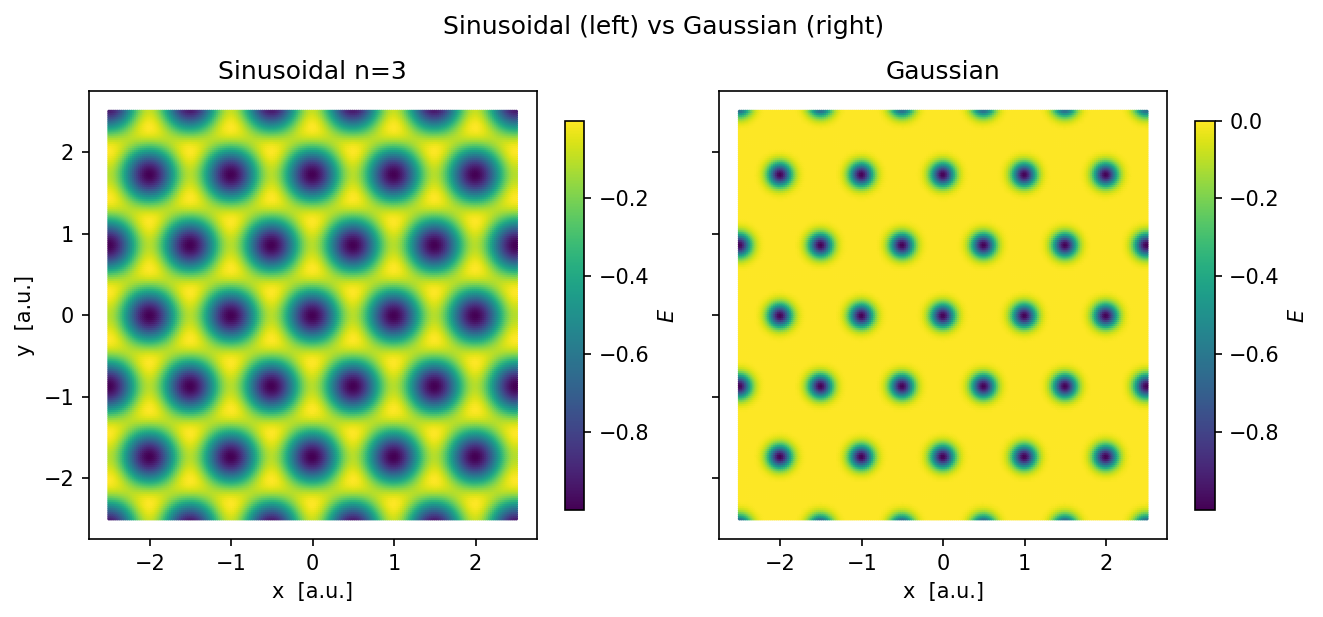

In [ ]:
params = {
    'well_shape': 'gaussian',
    'sub_basis':  [[0., 0.]],
    'b1':         [1., 0.],
    'b2':         [1/2., sqrt(3.)/2.],
    'epsilon':    1.,
    'sigma':      0.1,
    'a':          0.2,
    'b':          0.45,
}

pen_func, _, en_inputs_g = substrate_from_params(params)
en_g, _, _ = pen_func(p, np.array([0., 0.]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), dpi=150,
                                sharex=True, sharey=True)
fig.suptitle('Sinusoidal (left) vs Gaussian (right) ')

sc1 = ax1.scatter(p[:,0], p[:,1], c=en,   s=s0, cmap='viridis', rasterized=True)
sc2 = ax2.scatter(p[:,0], p[:,1], c=en_g, s=s0, cmap='viridis', rasterized=True)
plt.colorbar(sc1, ax=ax1, label=r'$E$', shrink=0.8)
plt.colorbar(sc2, ax=ax2, label=r'$E$', shrink=0.8)

for ax, t in [(ax1, 'Sinusoidal n=3'), (ax2, 'Gaussian')]:
    ax.set_aspect('equal')
    ax.set_title(t)
    ax.set_xlabel('x  [a.u.]')
ax1.set_ylabel('y  [a.u.]')

plt.tight_layout()
plt.show()